In [4]:
from psychoanalyze import plot, data
from psychoanalyze.plot import template
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import panel as pn
import holoviews as hv
from datetime import datetime
from sklearn.linear_model import LinearRegression as LinReg

pd.set_option('io.hdf.default_format','table')
pn.extension('plotly')

%load_ext autoreload
%autoreload 2

FileNotFoundError: [Errno 2] No such file or directory: 'data/2-calculated/impedances.csv'

In [134]:
df = data.load()
sessions = data.load('sessions')
curves = data.load('curves')
points = data.load('points')
points = points.drop(data.outliers['points'])

In [53]:
df = data.filter_curves(
        date_range=date_range,
        x_var=x_var,
        const_val=const_val,
        config=config,
    )

['1', '2', '3', 'test']

In [133]:
curves

x  \
Monkey Date       Ref PW Ref Freq Ref Dur Active Channels Return Channels         
U      2017-04-06 200    50       200     15              128               600   
       2017-04-07 200    50       200     15              128               300   
       2017-04-10 200    50       500     15              128               480   
       2017-04-11 200    50       500     15              128               500   
       2017-04-13 200    50       500     15              128               500   
...                                                                         ...   
Y      2017-12-01 200    50       200     112             128               580   
                                                          128               700   
                                                          128               850   
                                                          128               970   
                                                          128              1150   

                                                                            id  \
Monkey Date       Ref PW Ref Freq Ref Dur Active Channels Return Channels        
U      2017-04-06 200    50       200     15              128              192   
       2017-04-07 200    50       200     15              128              193   
       2017-04-10 200    50       500     15              128              195   
       2017-04-11 200    50       500     15              128              197   
       2017-04-13 200    50       500     15              128              199   
...                                                                        ...   
Y      2017-12-01 200    50       200     112             128              960   
                                                          128              961   
                                                          128              962   
                                                          128              963   
                                                          128              964   

                                                                           FAs  \
Monkey Date       Ref PW Ref Freq Ref Dur Active Channels Return Channels        
U      2017-04-06 200    50       200     15              128               30   
       2017-04-07 200    50       200     15              128               59   
       2017-04-10 200    50       500     15              128               73   
       2017-04-11 200    50       500     15              128               20   
       2017-04-13 200    50       500     15              128               15   
...                                                                        ...   
Y      2017-12-01 200    50       200     112             128                6   
                                                          128                2   
                                                          128                7   
                                                          128               15   
                                                          128                8   

                                                                           CRs  \
Monkey Date       Ref PW Ref Freq Ref Dur Active Channels Return Channels        
U      2017-04-06 200    50       200     15              128              230   
       2017-04-07 200    50       200     15              128              234   
       2017-04-10 200    50       500     15              128              126   
       2017-04-11 200    50       500     15              128               37   
       2017-04-13 200    50       500     15              128              188   
...                                                                        ...   
Y      2017-12-01 200    50       200     112             128               37   
                                                          128               33   
                                            

In [152]:
groups = ['Monkey','Active Channels']
curves['Ref X'] = curves.index.get_level_values('Ref Amp')
print(curves.index.names)
grouped = curves.groupby(groups)
u = grouped.get_group(('U', 15))
u.index
u.dropna(subset=['Ref X', 'location'])
x = group['Ref X'].values.reshape(-1, 1).tolist()
y = group['location'].values.tolist()
regression = LinReg(fit_intercept=fit_intercept).fit(x, y)
slope = regression.coef_[0]
intercept = regression.intercept_

# regressions = curves.groupby(groups).apply(data.regress)
# print(regressions.index.names)

['Monkey', 'Date', 'Ref Amp', 'Ref PW', 'Ref Freq', 'Ref Dur', 'Active Channels', 'Return Channels']


KeyError: 'Ref X'

In [265]:
params = ['id','location','width','gamma','lambda', 'Channel(s)','X dimension', 'min','max']
curves['Channel(s)'] = curves['Channel(s)'].astype('category')

In [5]:
df = sessions['Days'].to_frame().join(curves)

In [14]:
dff = df[df['Experiment Type'] == 'Discrimination']

Days  \
Monkey Date       Active Channels Ref Dur Ref Freq Ref Amp Ref PW Return Channels         
U      2017-04-06 15              200     50       600     200    128               286   
       2017-04-07 15              200     50       300     200    128               287   
       2017-04-10 15              500     50       480     200    128               290   
       2017-04-11 15              500     50       500     200    128               291   
       2017-04-13 15              500     50       500     200    128               293   
...                                                                                 ...   
Y      2017-12-01 112             200     50       580     200    128               630   
                                                   700     200    128               630   
                                                   850     200    128               630   
                                                   970     200    128               630   
                                                   1150    200    128               630   

                                                                                      id  \
Monkey Date       Active Channels Ref Dur Ref Freq Ref Amp Ref PW Return Channels          
U      2017-04-06 15              200     50       600     200    128              192.0   
       2017-04-07 15              200     50       300     200    128              193.0   
       2017-04-10 15              500     50       480     200    128              195.0   
       2017-04-11 15              500     50       500     200    128              197.0   
       2017-04-13 15              500     50       500     200    128              199.0   
...                                                                                  ...   
Y      2017-12-01 112             200     50       580     200    128              960.0   
                                                   700     200    128              961.0   
                                                   850     200    128              962.0   
                                                   970     200    128              963.0   
                                                   1150    200    128              964.0   

                                                                                    FAs  \
Monkey Date       Active Channels Ref Dur Ref Freq Ref Amp Ref PW Return Channels         
U      2017-04-06 15              200     50       600     200    128              30.0   
       2017-04-07 15              200     50       300     200    128              59.0   
       2017-04-10 15              500     50       480     200    128              73.0   
       2017-04-11 15              500     50       500     200    128              20.0   
       2017-04-13 15              500     50       500     200    128              15.0   
...                                                                                 ...   
Y      2017-12-01 112             200     50       580     200    128               6.0   
                                                   700     200    128               2.0   
                                                   850     200    128               7.0   
                                                   970     200    128              15.0   
                                                   1150    200    128               8.0   

                                                                                     CRs  \
Monkey Date       Active Channels Ref Dur Ref Freq Ref Amp Ref PW Return Channels          
U      2017-04-06 15              200     50       600     200    128              230.0   
       2017-04-07 15              200     50       300     200    128              234.0   
       2017-04-10 15              500     50       480     200    128              126.0   
       2017-04-11 15              500     50       500    

In [19]:
idx = pd.IndexSlice
dff.loc[[idx['U',:,:,:,:,600], ('Y',:,:,:,:,400)]]

SyntaxError: invalid syntax (<ipython-input-19-749fd0740746>, line 2)

In [15]:
weber_data = dff.groupby(['Monkey', 'Ref Amp'])['location'].agg(['mean', 'std', 'count'])
indices = dff.groupby(['Monkey', 'Ref Amp']).apply(lambda x: x.index.tolist()).to_frame(name='indices')

mean         std  count
Monkey Ref Amp                               
U      70       155.502241         NaN      1
       140       91.391582         NaN      1
       200      -11.022243    4.801399     35
       300      143.991031  110.326761     10
       320      172.276362         NaN      1
       400       41.719218   69.300804    123
       420       34.804135         NaN      1
       480       15.308221         NaN      1
       500      197.018832   97.857032     14
       580       49.330249         NaN      1
       600       69.147153   91.075459     16
       670       46.589463         NaN      1
       700      231.082107  119.154373      5
       800      131.875274   48.196348      8
       1000     136.545311   34.912407      6
       1100     218.397812   24.044926      2
       1200     211.335663   14.903833      2
       1300     136.747655   41.292112      2
       1400     266.495525         NaN      1
       1500     115.930801   62.430720      2
       1600     150.890515   34.510395      3
       2000     197.721815         NaN      1
       2400       4.636592         NaN      1
       2500     114.685452         NaN      1
Y      100       17.342383         NaN      1
       110       22.168707   11.569050      4
       130       21.609293         NaN      1
       150       22.293619   20.065244     12
       170       20.011159         NaN      1
       180        9.643618    6.771142      2
       190       41.911049         NaN      1
       200       41.057047   48.909275    113
       210       14.796041         NaN      1
       220      -15.371267         NaN      1
       240       24.334809         NaN      1
       250       29.569817   12.021526      3
       260       12.393583         NaN      1
       300       42.290349   17.590458      4
       340       36.893627         NaN      1
       350       59.646575         NaN      1
       400       51.472304   27.872144     33
       420      172.573993         NaN      1
       480       58.386104         NaN      1
       580       44.384346         NaN      1
       600       57.954069   29.483558     19
       700       81.876405         NaN      1
       850       49.331143         NaN      1
       970      137.091270         NaN      1
       1150      95.746735         NaN      1

In [17]:
data = weber_data.join(indices)
data

mean         std  count  \
Monkey Ref Amp                                  
U      70       155.502241         NaN      1   
       140       91.391582         NaN      1   
       200      -11.022243    4.801399     35   
       300      143.991031  110.326761     10   
       320      172.276362         NaN      1   
       400       41.719218   69.300804    123   
       420       34.804135         NaN      1   
       480       15.308221         NaN      1   
       500      197.018832   97.857032     14   
       580       49.330249         NaN      1   
       600       69.147153   91.075459     16   
       670       46.589463         NaN      1   
       700      231.082107  119.154373      5   
       800      131.875274   48.196348      8   
       1000     136.545311   34.912407      6   
       1100     218.397812   24.044926      2   
       1200     211.335663   14.903833      2   
       1300     136.747655   41.292112      2   
       1400     266.495525         NaN      1   
       1500     115.930801   62.430720      2   
       1600     150.890515   34.510395      3   
       2000     197.721815         NaN      1   
       2400       4.636592         NaN      1   
       2500     114.685452         NaN      1   
Y      100       17.342383         NaN      1   
       110       22.168707   11.569050      4   
       130       21.609293         NaN      1   
       150       22.293619   20.065244     12   
       170       20.011159         NaN      1   
       180        9.643618    6.771142      2   
       190       41.911049         NaN      1   
       200       41.057047   48.909275    113   
       210       14.796041         NaN      1   
       220      -15.371267         NaN      1   
       240       24.334809         NaN      1   
       250       29.569817   12.021526      3   
       260       12.393583         NaN      1   
       300       42.290349   17.590458      4   
       340       36.893627         NaN      1   
       350       59.646575         NaN      1   
       400       51.472304   27.872144     33   
       420      172.573993         NaN      1   
       480       58.386104         NaN      1   
       580       44.384346         NaN      1   
       600       57.954069   29.483558     19   
       700       81.876405         NaN      1   
       850       49.331143         NaN      1   
       970      137.091270         NaN      1   
       1150      95.746735         NaN      1   

                                                          indices  
Monkey Ref Amp                                                     
U      70       [(U, 2017-04-28 00:00:00, 15, 500, 50, 70, 200...  
       140      [(U, 2017-04-28 00:00:00, 15, 500, 50, 140, 20...  
       200      [(U, 2017-06-15 00:00:00, 15, 500, 50, 200, 10...  
       300      [(U, 2017-04-07 00:00:00, 15, 200, 50, 300, 20...  
       320      [(U, 2018-03-06 00:00:00, 112, 200, 50, 320, 2...  
       400      [(U, 2017-04-14 00:00:00, 15, 500, 50, 400, 20...  
       420      [(U, 2017-04-19 00:00:00, 15, 500, 50, 420, 20...  
       480      [(U, 2017-04-10 00:00:00, 15, 500, 50, 480, 20...  
       500      [(U, 2017-04-11 00:00:00, 15, 500, 50, 500, 20...  
       580      [(U, 2017-04-14 00:00:00, 15, 500, 50, 580, 20...  
       600      [(U, 2017-04-06 00:00:00, 15, 200, 50, 600, 20...  
       670      [(U, 2017-04-14 00:00:00, 15, 500, 50, 670, 20...  
       700      [(U, 2018-02-27 00:00:00, 112, 200, 50, 700, 2...  
       800      [(U, 2017-05-10 00:00:00, 15, 500, 50, 800, 20...  
       1000     [(U, 2018-02-26 00:00:00, 112, 200, 50, 1000, ...  
       1100     [(U, 2018-04-04 00:00:00, 15, 200, 50, 1100, 2...  
       1200     [(U, 2018-02-26 00:00:00, 112, 200, 50, 1200, ...  
       1300     [(U, 2018-03-14 00:00:00, 112, 200, 50, 1300, ...  
       1400     [(U, 2018-04-12 00:00:00, 15, 200, 50, 1400, 2...  
       1500     [(U, 2018-02-28 00:00:00, 112, 200, 50, 1500, ...  
       1600     [(U, 2018-

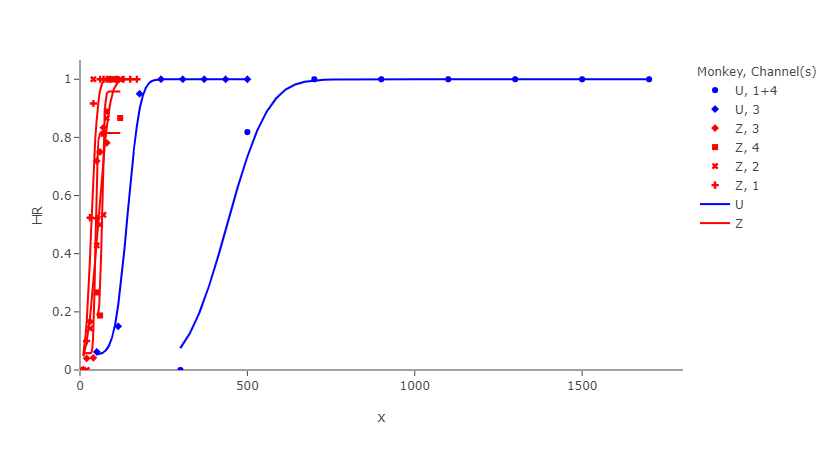

In [87]:
plot.psycho(dff)

In [131]:
fig_lines = px.line(
        fits,
        x='x',
        y='y',
        color='Monkey',
        legend_group='Date',
        template=template
    )
len(fig_lines.data)

2

In [127]:
fits = dff.apply(plot.add_fit, axis=1)
fits = pd.concat(
        [fits['x'].explode().to_frame(), fits['y'].explode().to_frame()],
        axis=1
    ).reset_index()

2

In [128]:
fits

,Monkey,Date,Active Channels,Return Channels,Ref Dur,Ref Freq,Ref Amp,Ref PW,x,y
0,U,2016-10-28,9,144,0,0,0,0,300,0.0752016
1,U,2016-10-28,9,144,0,0,0,0,328.571,0.126389
2,U,2016-10-28,9,144,0,0,0,0,357.143,0.197951
3,U,2016-10-28,9,144,0,0,0,0,385.714,0.289722
4,U,2016-10-28,9,144,0,0,0,0,414.286,0.397673
...,...,...,...,...,...,...,...,...,...,...
295,Z,2017-01-20,15,128,0,0,0,0,156.939,1
296,Z,2017-01-20,15,128,0,0,0,0,160.204,1
297,Z,2017-01-20,15,128,0,0,0,0,163.469,1
298,Z,2017-01-20,15,128,0,0,0,0,166.735,1


In [9]:
from scipy.special import erfc, erfcinv

def psy_fn(x, params, f):
    psi = params['gamma'] + (1 - params['gamma'] - params['lambda'])*f(x, params['location'], params['width'])
    return psi

def f(X, m, width):
#     from psignifit
    thresh_percent = 0.5
    alpha = 0.05
    C = my_norminv(1 - alpha, 0, 1) - my_norminv(alpha, 0, 1)
    return my_normcdf(X, (m - my_norminv(thresh_percent, 0, width / C)), width / C)

def my_normcdf(x,mu,sigma):
    z = (x-mu) / sigma
    p = .5*erfc(-z/np.sqrt(2))
    return p

def my_norminv(p,mu,sigma):
    x0 = -np.sqrt(2)*erfcinv(2*p)
    x = sigma*x0 + mu
    return x

thresh_percent = 0.5

In [234]:
dff[['x', 'y']] = dff.apply(foo, axis=1)

In [235]:
dff = dff.set_index('id', append=True)

In [236]:
dff_plot = pd.concat([dff['x'].explode().to_frame(), dff['y'].explode().to_frame()], axis=1)

In [239]:
dff_plot = dff_plot.reset_index()

In [245]:
fig = px.line(dff_plot, x='x', y='y', color='Monkey', line_group='id', template=template)

tuple

In [179]:
def foo(row):
    fit = plot.add_fit(row)
    return fit
    
curves[['x', 'y']] = curves.apply(foo, axis=1)